<a href="https://colab.research.google.com/github/Raikama/Projetos/blob/main/Desafio_agrupando_dados.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Desafio 1: Como estão divididas as vendas das lojas de departamentos na Região Centro-Oeste nos anos de 2017 e 2018? O mesmo estado permaneceu como o que mais vendeu nesta região?

Desafio 2: Analisando cada departamento, como estão divididos os modos de envio em cada um deles percentualmente?

In [1]:
#importação de bibliotecas
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
#seleção de cores a ser utilizadas nos gráficos
AZUL1, AZUL2, AZUL3, AZUL4,AZUL5 = '#042033','#2C526B', '#567C96', '#90AEC2', '#D0E0EB'
CINZA1, CINZA2, CINZA3, CINZA4, CINZA5 = '#212529', '#495057', '#adb5bd', '#dee2e6', '#f8f9fa'
VERMELHO1, LARANJA1, AMARELO1, VERDE1, VERDE2 = '#e76f51', '#f4a261',	'#e9c46a', '#4c956c', '#2a9d8f'

In [3]:
#importação dos dados
dados = pd.read_csv('https://raw.githubusercontent.com/alura-cursos/dataviz-graficos/master/dados/relatorio_vendas.csv')
dados.head(50)

,data_pedido,data_envio,modo_envio,nome_cliente,segmento_cliente,cidade,estado,regiao,departamento,tipo_produto,preco_base,preco_unit_sem_desc,desconto,preco_unit_venda,quantidade,vendas,lucro
0,2018-11-09,2018-11-12,Econômica,Thiago Silveira,B2C,Ribeirão Preto,São Paulo,Sudeste,Materiais de construção,encanamentos,409.70,445.33,0.000,445.33,2,890.66,71.26
1,2018-11-09,2018-11-12,Econômica,Thiago Silveira,B2C,Ribeirão Preto,São Paulo,Sudeste,Materiais de construção,ferramentas,705.10,829.53,0.000,829.53,3,2488.59,373.29
2,2018-06-13,2018-06-17,Econômica,Giovanna Lima,B2B,Rio de Janeiro,Rio de Janeiro,Sudeste,Jardinagem e paisagismo,sementes,19.02,24.86,0.000,24.86,2,49.72,11.68
3,2017-10-12,2017-10-19,Entrega padrão,Ana Júlia da Cruz,B2C,Foz do Iguaçu,Paraná,Sul,Materiais de construção,materiais de revestimento,781.38,840.19,0.225,651.15,5,3255.75,-651.15
4,2017-10-12,2017-10-19,Entrega padrão,Ana Júlia da Cruz,B2C,Foz do Iguaçu,Paraná,Sul,Jardinagem e paisagismo,vasos,35.88,42.24,0.100,38.02,2,76.04,4.28
5,2016-06-10,2016-06-15,Entrega padrão,Sophia Dias,B2C,Rio de Janeiro,Rio de Janeiro,Sudeste,Materiais de construção,iluminação,20.29,23.73,0.000,23.73,7,166.11,24.08
6,2016-06-10,2016-06-15,Entrega padrão,Sophia Dias,B2C,Rio de Janeiro,Rio de Janeiro,Sudeste,Jardinagem e paisagismo,decoração de jardim,5.35,6.19,0.000,6.19,4,24.76,3.36
7,2016-06-10,2016-06-15,Entrega padrão,Sophia Dias,B2C,Rio de Janeiro,Rio de Janeiro,Sudeste,Automotivo,pneus,488.35,571.17,0.100,514.05,6,3084.30,154.20
8,2016-06-10,2016-06-15,Entrega padrão,Sophia Dias,B2C,Rio de Janeiro,Rio de Janeiro,Sudeste,Jardinagem e paisagismo,ferramentas de jardinagem,17.69,23.30,0.100,20.97,3,62.91,9.84
9,2016-06-10,2016-06-15,Entrega padrão,Sophia Dias,B2C,Rio de Janeiro,Rio de Janeiro,Sudeste,Jardinagem e paisagismo,mobiliário de exterior,66.41,78.13,0.000,78.13,5,390.65,58.60


In [4]:
dados.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8940 entries, 0 to 8939
Data columns (total 17 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   data_pedido          8940 non-null   object 
 1   data_envio           8940 non-null   object 
 2   modo_envio           8940 non-null   object 
 3   nome_cliente         8940 non-null   object 
 4   segmento_cliente     8940 non-null   object 
 5   cidade               8940 non-null   object 
 6   estado               8940 non-null   object 
 7   regiao               8940 non-null   object 
 8   departamento         8940 non-null   object 
 9   tipo_produto         8940 non-null   object 
 10  preco_base           8940 non-null   float64
 11  preco_unit_sem_desc  8940 non-null   float64
 12  desconto             8940 non-null   float64
 13  preco_unit_venda     8940 non-null   float64
 14  quantidade           8940 non-null   int64  
 15  vendas               8940 non-null   f

In [5]:
#transformação dos tipos de dados para datetime
dados['data_pedido'] = pd.to_datetime(dados['data_pedido'], format='%Y-%m-%d')
dados['data_envio'] = pd.to_datetime(dados['data_envio'], format='%Y-%m-%d')

#criação de colunas em anos
dados['ano_pedido'] = dados['data_pedido'].dt.year
dados['ano_envio'] = dados['data_envio'].dt.year
dados.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8940 entries, 0 to 8939
Data columns (total 19 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   data_pedido          8940 non-null   datetime64[ns]
 1   data_envio           8940 non-null   datetime64[ns]
 2   modo_envio           8940 non-null   object        
 3   nome_cliente         8940 non-null   object        
 4   segmento_cliente     8940 non-null   object        
 5   cidade               8940 non-null   object        
 6   estado               8940 non-null   object        
 7   regiao               8940 non-null   object        
 8   departamento         8940 non-null   object        
 9   tipo_produto         8940 non-null   object        
 10  preco_base           8940 non-null   float64       
 11  preco_unit_sem_desc  8940 non-null   float64       
 12  desconto             8940 non-null   float64       
 13  preco_unit_venda     8940 non-nul

In [6]:
dados_centro_oeste = dados.copy()

In [90]:
#Selecionando os dados desejados por região e anos(Centro-Oeste, 2017 e 2018)
dados_centro_oeste = dados.query('regiao == "Centro-Oeste" & (ano_pedido >= 2017 & ano_pedido <=2018)')


dados_centro_oeste

,data_pedido,data_envio,modo_envio,nome_cliente,segmento_cliente,cidade,estado,regiao,departamento,tipo_produto,preco_base,preco_unit_sem_desc,desconto,preco_unit_venda,quantidade,vendas,lucro,ano_pedido,ano_envio
26,2017-09-18,2017-09-22,Entrega padrão,Felipe Rodrigues,B2C,Brasília,Distrito Federal,Centro-Oeste,Materiais de construção,encanamentos,1902.04,1996.89,0.25,1497.67,7,10483.69,-2830.59,2017,2017
27,2017-09-18,2017-09-22,Entrega padrão,Felipe Rodrigues,B2C,Brasília,Distrito Federal,Centro-Oeste,Jardinagem e paisagismo,ferramentas de jardinagem,22.35,25.15,0.35,16.35,2,32.70,-12.00,2017,2017
28,2017-09-18,2017-09-22,Entrega padrão,Felipe Rodrigues,B2C,Brasília,Distrito Federal,Centro-Oeste,Materiais de construção,iluminação,131.96,156.40,0.10,140.76,3,422.28,26.40,2017,2017
29,2017-09-18,2017-09-22,Entrega padrão,Felipe Rodrigues,B2C,Brasília,Distrito Federal,Centro-Oeste,Jardinagem e paisagismo,fertilizantes,4.61,6.17,0.10,5.55,2,11.10,1.88,2017,2017
30,2017-09-18,2017-09-22,Entrega padrão,Felipe Rodrigues,B2C,Brasília,Distrito Federal,Centro-Oeste,Jardinagem e paisagismo,decoração de jardim,46.16,54.33,0.10,48.90,6,293.40,16.44,2017,2017
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8737,2018-07-04,2018-07-04,24 horas,Marcela Moreira,B2B,Brasília,Distrito Federal,Centro-Oeste,Jardinagem e paisagismo,pesticidas,71.10,93.63,0.10,84.27,5,421.35,65.85,2018,2018
8833,2017-05-30,2017-06-01,Envio rápido,Kaique Rocha,B2B,Cuiabá,Mato Grosso,Centro-Oeste,Jardinagem e paisagismo,pesticidas,80.13,107.11,0.10,96.40,3,289.20,48.81,2017,2017
8884,2018-04-08,2018-04-13,Entrega padrão,Kaique Barbosa,B2C,Brasília,Distrito Federal,Centro-Oeste,Jardinagem e paisagismo,mobiliário de exterior,36.57,42.22,0.10,38.00,3,114.00,4.29,2018,2018
8885,2018-04-08,2018-04-13,Entrega padrão,Kaique Barbosa,B2C,Brasília,Distrito Federal,Centro-Oeste,Jardinagem e paisagismo,vasos,39.56,46.27,0.10,41.64,3,124.92,6.24,2018,2018


In [8]:
#agrupamento dos dados por anos, estado e somando as vendas de cada estado
vendas_centro_oeste = dados_centro_oeste.groupby(['ano_pedido', 'estado'])['vendas'].agg('sum')

vendas_centro_oeste


ano_pedido  estado            
2017        Distrito Federal       64308.70
            Goiás                  66078.33
            Mato Grosso             5259.46
            Mato Grosso do Sul     13568.51
2018        Distrito Federal      103036.69
            Goiás                  79801.93
            Mato Grosso            10980.07
            Mato Grosso do Sul     14250.02
Name: vendas, dtype: float64

In [9]:
#Utilizando crosstab para categorizar em anos e Estados
vendas_centro_oeste = pd.crosstab(dados_centro_oeste['ano_pedido'], dados_centro_oeste['estado'], values=dados_centro_oeste['vendas'], aggfunc='sum')

vendas_centro_oeste

estado,Distrito Federal,Goiás,Mato Grosso,Mato Grosso do Sul
ano_pedido,,,,
2017,64308.70,66078.33,5259.46,13568.51
2018,103036.69,79801.93,10980.07,14250.02


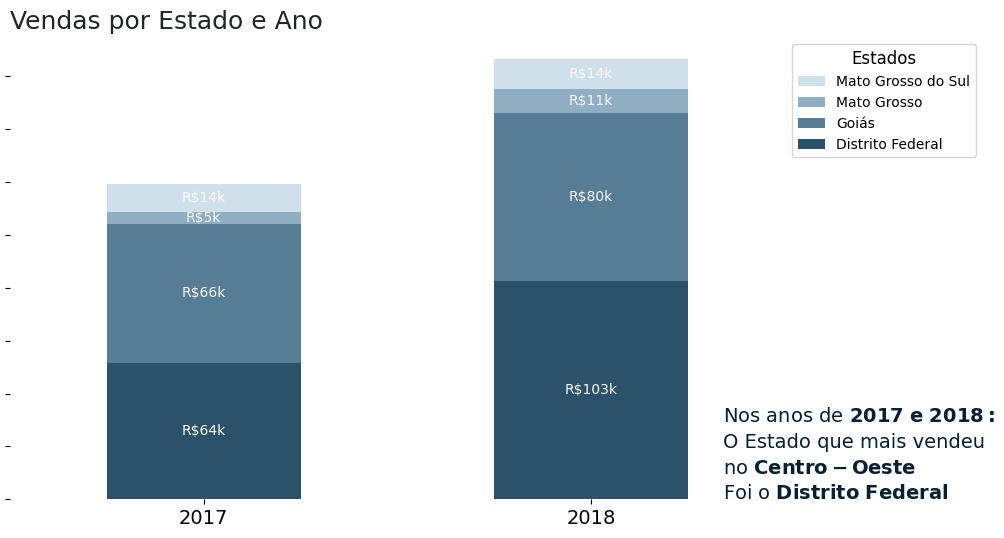

In [10]:

#Criação do nosso gráfico em barras empilhadas do Centro - Oeste
def grafico_barras_centro_oeste():
#definindo as cores padrão do nosso gráfico
  cores = [AZUL2,AZUL3,AZUL4,AZUL5]

#plotando o nosso grafico de barras empilhadas
  ax = vendas_centro_oeste.plot(kind='bar',stacked=True, figsize=(10,6), color= cores)

#formatando o layout do graficos
  ax.set_title('Vendas por Estado e Ano', loc= 'left', fontsize= 18, color= CINZA1)
  ax.set_xlabel('')
  ax.set_ylabel('')
  ax.set_yticklabels([])
  ax.xaxis.set_tick_params(labelsize = 14, rotation = 0)
  ax.set_frame_on(False)

#criação da legenda
  ax.legend(bbox_to_anchor = (1,1), reverse = True, title = 'Estados', title_fontsize = 12)

#Colocando os valores no gráfico e centralizando nas colunas
  for container in ax.containers:
    labels = [f'R${valor.get_height()/1000:,.0f}k'.replace(',', '.') for valor in container]
    ax.bar_label(container, labels=labels, label_type='center', fontsize=10, color = CINZA5)

  #Criação do texto no gráfico
  ax.text(1.34,1.0, 'Nos anos de $\\bf{2017}$ $\\bf{e}$ $\\bf{2018:}$\n'
  'O Estado que mais vendeu\n'
  'no $\\bf{Centro-Oeste}$ \n'
  'Foi o $\\bf{Distrito}$ $\\bf{Federal}$', fontsize= 14, linespacing= 1.45, color = AZUL1)
  return ax
ax = grafico_barras_centro_oeste()


Desafio 2: Analisando cada departamento, como estão divididos os modos de envio em cada um deles percentualmente?

In [30]:
#variavel departamentos
df_departamentos = dados.copy()
df_departamentos

#ajuntando os departamento e o modo de envio e somando as vendas
df_departamentos.groupby(['departamento', 'modo_envio'])['vendas'].agg('sum')

#Categorizando o numeros de vezes que a colunas departamento e modo de envio aparece em % e valores absolutos
teste = pd.crosstab(index = df_departamentos.modo_envio, columns=df_departamentos.departamento,normalize='index')
teste1 = pd.crosstab(index = df_departamentos.modo_envio, columns=df_departamentos.departamento)
teste1

departamento,Automotivo,Jardinagem e paisagismo,Materiais de construção
modo_envio,,,
24 horas,85,301,109
Econômica,321,1035,379
Entrega padrão,974,3284,1103
Envio rápido,262,803,284


In [31]:
teste

departamento,Automotivo,Jardinagem e paisagismo,Materiais de construção
modo_envio,,,
24 horas,0.171717,0.608081,0.220202
Econômica,0.185014,0.596542,0.218444
Entrega padrão,0.181683,0.612572,0.205745
Envio rápido,0.194218,0.595256,0.210526


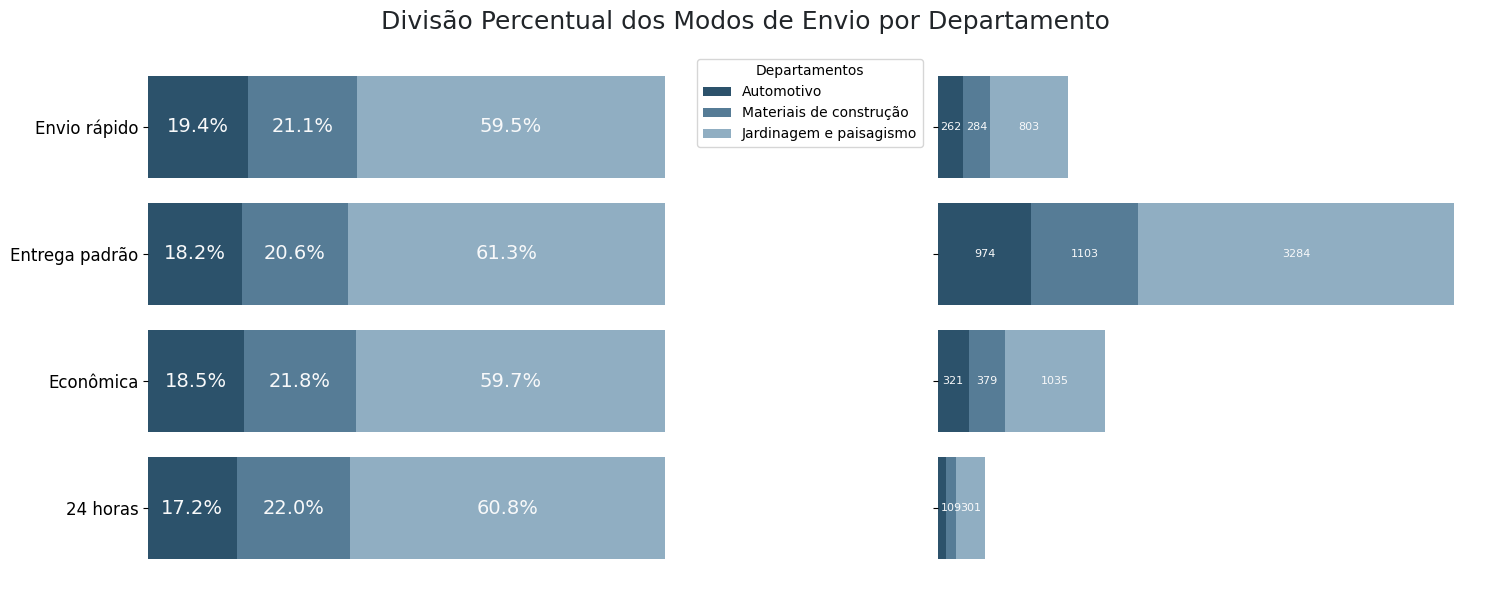

In [89]:
#plotando o gráfico em subplots(mais de um gráfico de uma área)
fig, axs = plt.subplots(1,2, figsize=(15,6),sharey=True)

#variaveis importantes para dizer onde estará dispostos os valores
left_automotivo = teste['Automotivo']
left_materiais = teste['Automotivo'] + teste['Materiais de construção']

left_automotivo1 = teste1['Automotivo']
left_materiais1 = teste1['Automotivo'] + teste1['Materiais de construção']

#criação do primeiro gráfico
axs[0].barh(teste.index, teste['Automotivo'], label='Automotivo', color=AZUL2)
axs[0].barh(teste.index, teste['Materiais de construção'], left=left_automotivo, label='Materiais de construção', color=AZUL3)
axs[0].barh(teste.index, teste['Jardinagem e paisagismo'], left=left_materiais, label='Jardinagem e paisagismo', color=AZUL4)

#formatando o layout do gráfico 1
axs[0].set_xlabel('')
axs[0].set_ylabel('')
axs[0].set_xticks([])
axs[0].yaxis.set_tick_params(labelsize=12)
axs[0].set_frame_on(False)

#definindo o titulo da figura dos dois gráficos
fig.suptitle('Divisão Percentual dos Modos de Envio por Departamento', fontsize=18, ha='center', color=CINZA1)

#Valores que vão conter em % no gráfico
for container in axs[0].containers:
    labels = [f'{valor.get_width()*100:.1f}%' for valor in container]
    axs[0].bar_label(container, label_type='center', labels=labels, fontsize=14, color=CINZA5)

#Definindo o tipo do segundo gráfico
axs[1].barh(teste1.index, teste1['Automotivo'], color=AZUL2)
axs[1].barh(teste1.index, teste1['Materiais de construção'], left=left_automotivo1, color=AZUL3)
axs[1].barh(teste1.index, teste1['Jardinagem e paisagismo'], left = left_materiais1, color=AZUL4)

#formatando o layout do 2 gráfico
axs[1].set_xlabel('')
axs[1].set_ylabel('')
axs[1].set_xticks([])
axs[1].yaxis.set_tick_params(labelsize=12)
axs[1].set_frame_on(False)
axs[0].legend(title='Departamentos', bbox_to_anchor=(1, 1))


#textos que estarão contidos em valores absolutos
for container in axs[1].containers:
    labels = [str(valor.get_width()) if valor.get_width()>100 else '' for valor in container]
    axs[1].bar_label(container, label_type='center', labels=labels, fontsize=8, color=CINZA5)
plt.tight_layout()


fig.show()

